In [1]:
import pandas as pd
import numpy as np
import os
import sys
notebook_dir = os.path.abspath(os.path.dirname(''))
project_root = os.path.dirname(notebook_dir)
sys.path.append(project_root)
import pandas as pd
from src.utils.db_utils import get_connection, execute_query


from src.features import team_level_features_class
from src.models import model
from src.utils.y_variable import build_spread_variable

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

In [2]:
nfl_model=model.NFLPredictor()
nfl_model.build_x_y_variable()

Successfully connected to the database!
Successfully connected to the database!
creating efficiency stats


100%|██████████| 5/5 [00:00<00:00, 618.61it/s]


building team stats


100%|██████████| 20/20 [00:21<00:00,  1.08s/it]


In [3]:
nfl_model.x_y

,home team defensive turnovers,away team defensive turnovers,home team offensive turnovers,away team offensive turnovers,home team defensive total_yards,away team defensive total_yards,home team offensive total_yards,away team offensive total_yards,home team defensive first_downs,away team defensive first_downs,...,away team offensive rushing efficiency_normalized,home team defensive third down efficiency_normalized,away team defensive third down efficiency_normalized,home team offensive third down efficiency_normalized,away team offensive third down efficiency_normalized,home team defensive team points_normalized,away team defensive team points_normalized,home team offensive team points_normalized,away team offensive team points_normalized,spread
2022_1_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
2022_1_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
2022_1_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-16
2022_1_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2022_1_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024_20_1,1.411765,1.0,0.882353,0.888889,342.352941,324.555556,409.529412,368.555556,19.470588,19.666667,...,0.820783,-1.904785,0.046836,1.654829,1.315102,-0.925893,-0.019363,2.383509,1.248201,-14
2024_20_2,1.666667,1.222222,0.833333,0.777778,279.666667,348.444444,362.888889,329.166667,17.222222,20.111111,...,-0.923891,-1.046735,0.282563,0.218144,-0.907273,-1.836786,-0.316085,0.955388,-0.203135,6
2024_20_3,1.777778,0.944444,0.444444,0.611111,335.0,321.722222,365.333333,427.111111,20.5,18.944444,...,3.083894,0.703959,0.124211,1.04149,1.846582,-0.686988,-0.686988,1.85929,1.73198,2
2024_21_0,1.684211,1.210526,0.789474,0.842105,286.105263,334.894737,362.210526,374.473684,17.263158,20.210526,...,0.724137,-1.019835,-0.059134,0.214791,1.189374,-1.813075,0.097323,0.967631,1.449517,32


In [4]:
df_out=nfl_model.build_single_game_features("KAN", "BUF")
df_out

,home team defensive turnovers,away team defensive turnovers,home team offensive turnovers,away team offensive turnovers,home team defensive total_yards,away team defensive total_yards,home team offensive total_yards,away team offensive total_yards,home team defensive first_downs,away team defensive first_downs,...,away team offensive rushing efficiency_normalized,home team defensive third down efficiency_normalized,away team defensive third down efficiency_normalized,home team offensive third down efficiency_normalized,away team offensive third down efficiency_normalized,home team defensive team points_normalized,away team defensive team points_normalized,home team offensive team points_normalized,away team offensive team points_normalized,spread
KAN_BUF,1.111111,1.842105,0.777778,0.421053,321.5,339.263158,321.222222,360.473684,19.222222,20.631579,...,0.353803,1.021533,1.067652,1.30311,1.056126,-1.386558,-0.652553,-0.024252,1.810932,NaN


In [4]:
nfl_model.spread_dict

{'2022_1': [['TEN',
   'LAC',
   'DAL',
   'SEA',
   'LAR',
   'ATL',
   'CAR',
   'CHI',
   'CIN',
   'DET',
   'HOU',
   'MIA',
   'NYJ',
   'WAS',
   'ARI',
   'MIN'],
  ['NYG',
   'LVR',
   'TAM',
   'DEN',
   'BUF',
   'NOR',
   'CLE',
   'SFO',
   'PIT',
   'PHI',
   'IND',
   'NWE',
   'BAL',
   'JAX',
   'KAN',
   'GNB'],
  [-1, 5, -16, 1, -21, -1, -2, 9, -3, -3, 0, 13, -15, 6, -23, 16]],
 '2022_2': [['KAN',
   'CLE',
   'DET',
   'JAX',
   'NOR',
   'NYG',
   'PIT',
   'BAL',
   'LAR',
   'SFO',
   'DAL',
   'DEN',
   'LVR',
   'GNB',
   'BUF',
   'PHI'],
  ['LAC',
   'NYJ',
   'WAS',
   'IND',
   'TAM',
   'CAR',
   'NWE',
   'MIA',
   'ATL',
   'SEA',
   'CIN',
   'HOU',
   'ARI',
   'CHI',
   'TEN',
   'MIN'],
  [3, -1, 9, 24, -10, 3, -3, -4, 4, 20, 3, 7, -6, 17, 34, 17]],
 '2022_3': [['CLE',
   'CAR',
   'CHI',
   'IND',
   'MIA',
   'MIN',
   'NWE',
   'NYJ',
   'TEN',
   'WAS',
   'LAC',
   'ARI',
   'SEA',
   'TAM',
   'DEN',
   'NYG'],
  ['PIT',
   'NOR',
   'HOU',
   

In [5]:
# model_parameters={"n_estimators": [500,1000, 1500,2000],
#                      "max_depth": [1,3,5,10],
#                      "min_samples_leaf": [.01,.05,.1]}
# nfl_model.build_random_forest_model(model_parameters)

In [6]:
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 3, 4, 5],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4, 0.5]
}

nfl_model.build_xg_boost_model(param_dist)

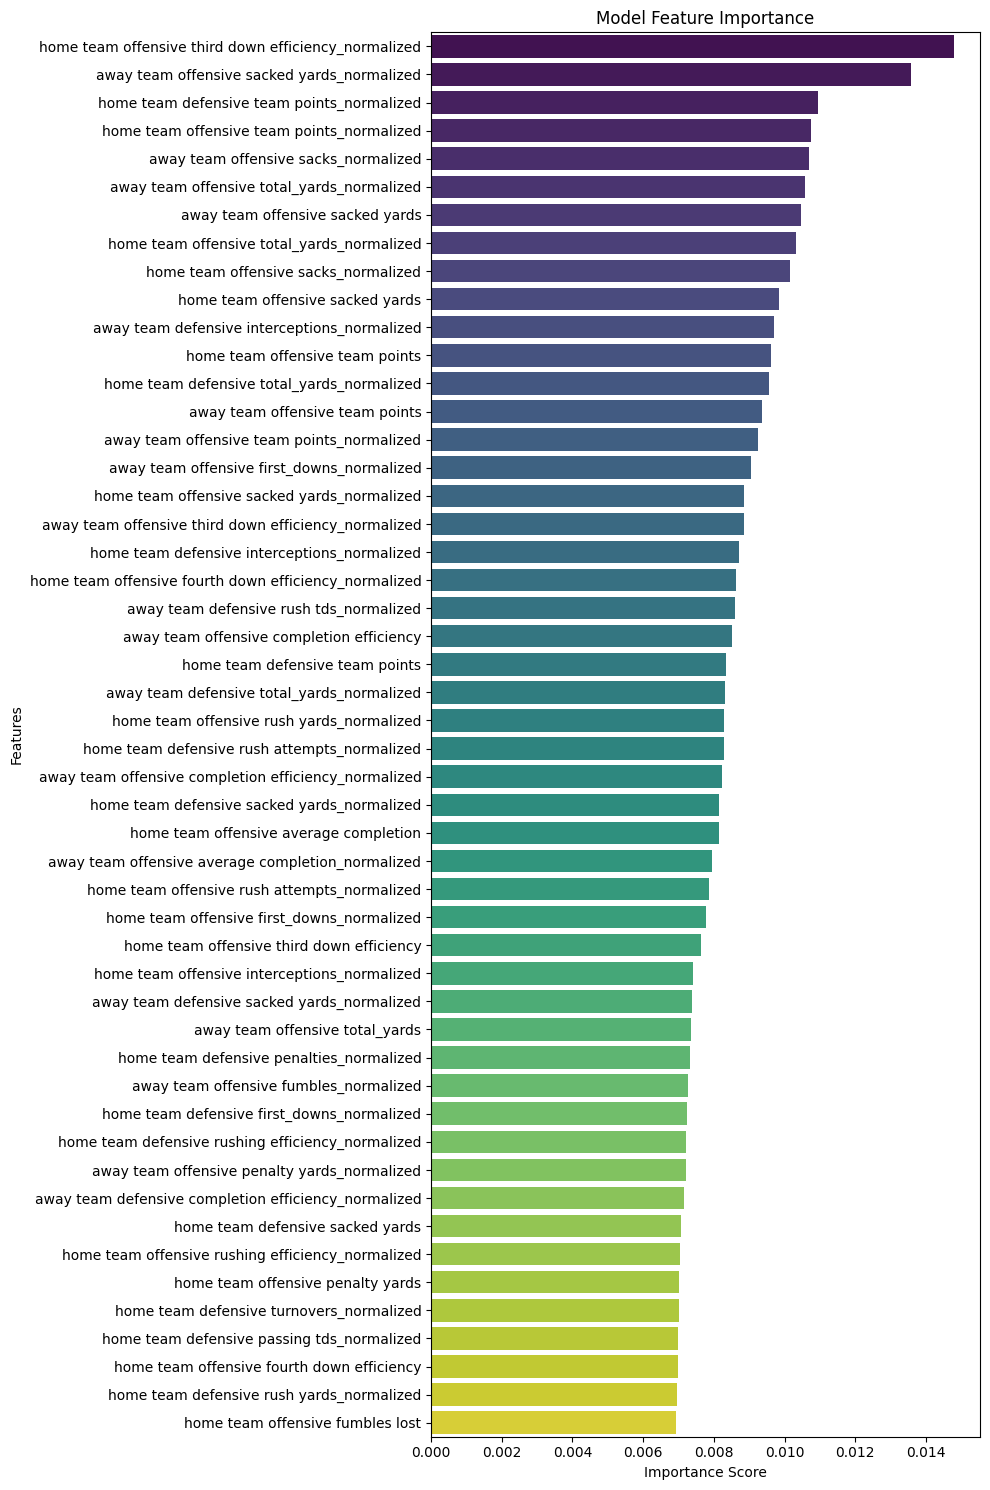

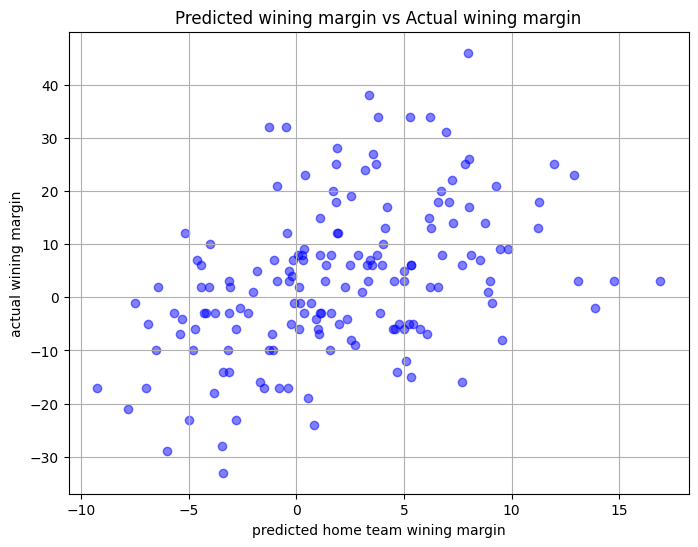

In [7]:
nfl_model.model_prediction(nfl_model.xg_model, x=nfl_model.x_test.to_numpy(),plot_feature_importance=True, plot_scatter=True)

In [8]:
nfl_model.build_x_y_variable()
x_y=nfl_model.x_y.dropna()
x_y

,home team defensive turnovers,away team defensive turnovers,home team offensive turnovers,away team offensive turnovers,home team defensive total_yards,away team defensive total_yards,home team offensive total_yards,away team offensive total_yards,home team defensive first_downs,away team defensive first_downs,...,away team offensive rushing efficiency_normalized,home team defensive third down efficiency_normalized,away team defensive third down efficiency_normalized,home team offensive third down efficiency_normalized,away team offensive third down efficiency_normalized,home team defensive team points_normalized,away team defensive team points_normalized,home team offensive team points_normalized,away team offensive team points_normalized,spread
2022_2_0,0.0,3.0,1.0,0.0,282.0,320.0,488.0,355.0,18.0,18.0,...,-1.450879,-1.042953,0.250199,1.327826,0.085989,-0.003575,-0.232382,2.627699,0.339635,3
2022_2_12,0.0,1.0,3.0,0.0,355.0,488.0,320.0,282.0,18.0,33.0,...,0.132705,0.085989,1.327826,0.250199,-1.042953,0.339635,2.627699,-0.232382,-0.003575,-6
2022_2_15,1.0,2.0,0.0,0.0,386.0,338.0,455.0,395.0,23.0,21.0,...,0.003602,1.440721,-0.516113,1.095397,-0.678218,1.59807,-1.60522,1.94128,0.225231,17
2022_3_1,0.0,1.5,1.5,3.0,310.0,338.0,268.0,346.5,20.5,19.5,...,2.104458,-0.064837,-0.556289,-1.167275,-0.786094,0.167177,0.243601,-0.192246,-0.397309,8
2022_3_2,1.5,1.5,1.0,0.5,372.5,433.5,216.0,266.5,21.5,26.5,...,-0.88079,1.167535,-0.69886,-1.303038,-1.360476,-0.444214,-0.520638,-0.944143,-0.944143,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024_20_1,1.411765,1.0,0.882353,0.888889,342.352941,324.555556,409.529412,368.555556,19.470588,19.666667,...,0.820783,-1.904785,0.046836,1.654829,1.315102,-0.925893,-0.019363,2.383509,1.248201,-14
2024_20_2,1.666667,1.222222,0.833333,0.777778,279.666667,348.444444,362.888889,329.166667,17.222222,20.111111,...,-0.923891,-1.046735,0.282563,0.218144,-0.907273,-1.836786,-0.316085,0.955388,-0.203135,6
2024_20_3,1.777778,0.944444,0.444444,0.611111,335.0,321.722222,365.333333,427.111111,20.5,18.944444,...,3.083894,0.703959,0.124211,1.04149,1.846582,-0.686988,-0.686988,1.85929,1.73198,2
2024_21_0,1.684211,1.210526,0.789474,0.842105,286.105263,334.894737,362.210526,374.473684,17.263158,20.210526,...,0.724137,-1.019835,-0.059134,0.214791,1.189374,-1.813075,0.097323,0.967631,1.449517,32


In [9]:
nfl_model.predictions

array([13.10211   ,  5.33347   ,  8.1008    ,  2.8467274 ,  3.9643993 ,
        9.004962  , -1.9939121 ,  4.224128  , -0.8246988 , -6.908272  ,
        1.3516157 ,  6.941565  ,  6.7320914 ,  5.024276  ,  1.5804642 ,
        0.13899608,  1.5977162 ,  3.4970105 ,  8.890541  , -3.1050987 ,
        7.686854  , -1.2721709 , -0.24375202,  6.59069   , -0.35393924,
        1.1636418 ,  9.091967  ,  4.048298  ,  3.697208  , -3.4654193 ,
       -3.7616136 ,  2.5457304 ,  0.09963676, -7.4994783 ,  7.9938664 ,
        1.0785567 ,  9.275606  , -2.7869053 ,  0.7031645 , -4.782315  ,
        0.11288157, -1.2874784 ,  3.8834517 ,  0.35199952,  0.81030244,
        3.414674  , -4.0146794 , -1.8289036 , -4.294066  , -3.8115652 ,
        4.7817698 ,  2.543746  , -4.9782357 ,  9.532174  , -6.4982915 ,
        1.9112114 , -0.40725628, -1.1084146 , -2.2585948 ,  1.969445  ,
       16.91131   , -1.027338  ,  4.133598  ,  6.206669  ,  2.331485  ,
        5.741643  ,  1.5939132 ,  3.0695376 , -0.11814351, 12.91

In [15]:
model=nfl_model.xg_model.fit(x_y.iloc[:-2,:-1].dropna().to_numpy(), x_y.iloc[:-2,-1].dropna().to_numpy())
model.predict(x_y.iloc[-2:,:-1].to_numpy())

array([1.5280378, 1.8166403], dtype=float32)